In [3]:
import shutil
import random
import os

dataset_path = '/kaggle/input/humanfacesdataset/Human Faces Dataset'
real_images_path = os.path.join(dataset_path, 'Real Images')
ai_generated_images_path = os.path.join(dataset_path, 'AI-Generated Images')

output_path = '/kaggle/working/'
train_path = os.path.join(output_path, 'train')
val_path = os.path.join(output_path, 'val')
test_path = os.path.join(output_path, 'test')

for path in [train_path, val_path, test_path]:
    os.makedirs(os.path.join(path, 'Real Images'), exist_ok = True)
    os.makedirs(os.path.join(path, 'AI-Generated Images'), exist_ok = True)

train_split = 0.7
val_split = 0.15
test_split = 0.15

def split_and_copy_images(source_dir, dest_dirs, split_ratios):
    images = os.listdir(source_dir)
    random.shuffle(images)
    
    train_size = int(len(images) * split_ratios[0])
    val_size = int(len(images) * split_ratios[1])
    
    for i, img in enumerate(images):
        if i < train_size:
            dest_dir = dest_dirs[0]
        elif i < train_size + val_size:
            dest_dir = dest_dirs[1]
        else:
            dest_dir = dest_dirs[2]
            
        shutil.copy(os.path.join(source_dir, img), os.path.join(dest_dir, img))

split_and_copy_images(real_images_path, [os.path.join(train_path, 'Real Images'), os.path.join(val_path, 'Real Images'), os.path.join(test_path, 'Real Images')], [train_split, val_split, test_split])
split_and_copy_images(ai_generated_images_path, [os.path.join(train_path, 'AI-Generated Images'), os.path.join(val_path, 'AI-Generated Images'), os.path.join(test_path, 'AI-Generated Images')], [train_split, val_split, test_split])

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_height, img_width = 224, 224
batch_size = 32

train_datagen = ImageDataGenerator(rescale = 1./255)
val_datagen = ImageDataGenerator(rescale = 1./255)
test_datagen = ImageDataGenerator(rescale = 1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size = (img_height, img_width),
    batch_size = batch_size,
    class_mode = 'binary'
)

val_generator = val_datagen.flow_from_directory(
    val_path,
    target_size = (img_height, img_width),
    batch_size = batch_size,
    class_mode = 'binary'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size = (img_height, img_width),
    batch_size = batch_size,
    class_mode = 'binary'
)

2026-01-16 21:40:18.733861: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768599619.339379      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768599619.510606      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768599620.838966      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768599620.839017      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768599620.839020      55 computation_placer.cc:177] computation placer alr

Found 8768 images belonging to 2 classes.
Found 2671 images belonging to 2 classes.
Found 2681 images belonging to 2 classes.


In [5]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = ResNet50(weights = 'imagenet', include_top = False, input_shape = (img_height, img_width, 3))

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation ='relu')(x)
predictions = Dense(1, activation ='sigmoid')(x)

model = Model(inputs = base_model.input, outputs = predictions)

for layer in base_model.layers:
    layer.trainable = False

model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

I0000 00:00:1768599700.811372      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1768599700.815376      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
history = model.fit(
    train_generator,
    validation_data = val_generator,
    epochs = 10
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1768599829.771471     125 service.cc:152] XLA service 0x7f902c006f30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768599829.771508     125 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1768599829.771512     125 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1768599831.719404     125 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/274 ━━━━━━━━━━━━━━━━━━━━ 23s 87ms/step - accuracy: 0.5391 - loss: 0.7141   

I0000 00:00:1768599837.530023     125 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


274/274 ━━━━━━━━━━━━━━━━━━━━ 52s 138ms/step - accuracy: 0.6874 - loss: 0.5768 - val_accuracy: 0.9083 - val_loss: 0.3122
Epoch 2/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 35s 128ms/step - accuracy: 0.9030 - loss: 0.2804 - val_accuracy: 0.9277 - val_loss: 0.1934
Epoch 3/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 36s 130ms/step - accuracy: 0.9499 - loss: 0.1698 - val_accuracy: 0.9697 - val_loss: 0.1226
Epoch 4/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 34s 125ms/step - accuracy: 0.9659 - loss: 0.1246 - val_accuracy: 0.9753 - val_loss: 0.0920
Epoch 5/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 36s 130ms/step - accuracy: 0.9714 - loss: 0.1031 - val_accuracy: 0.9835 - val_loss: 0.0727
Epoch 6/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 35s 127ms/step - accuracy: 0.9764 - loss: 0.0820 - val_accuracy: 0.9712 - val_loss: 0.0932
Epoch 7/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 35s 129ms/step - accuracy: 0.9704 - loss: 0.0853 - val_accuracy: 0.9764 - val_loss: 0.0666
Epoch 8/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 35s 129ms/step - accuracy: 0.9826 - loss: 0.0606 - val

In [7]:
test_loss, test_acc = model.evaluate(test_generator)
print(f'Test Loss: {test_loss}')
print(f'Test Accuracy: {test_acc}')

84/84 ━━━━━━━━━━━━━━━━━━━━ 13s 153ms/step - accuracy: 0.9896 - loss: 0.0411
Test Loss: 0.040526289492845535
Test Accuracy: 0.9899291396141052


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


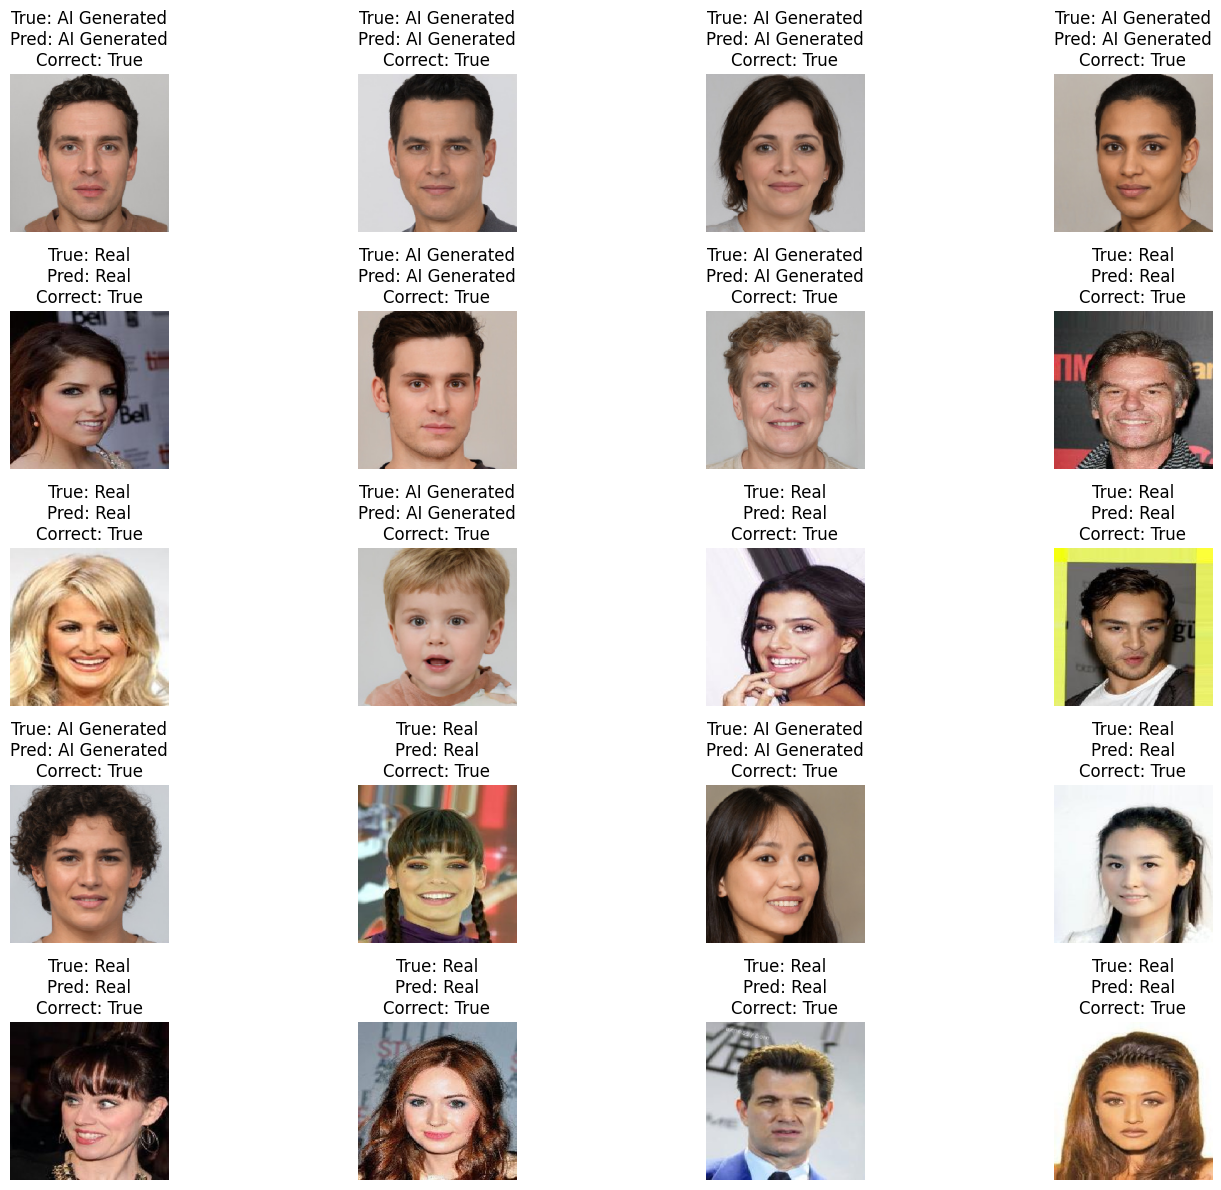

,Image Index,True Label,Predicted Label,Correct
0,0,AI Generated,AI Generated,True
1,1,AI Generated,AI Generated,True
2,2,AI Generated,AI Generated,True
3,3,AI Generated,AI Generated,True
4,4,Real,Real,True
5,5,AI Generated,AI Generated,True
6,6,AI Generated,AI Generated,True
7,7,Real,Real,True
8,8,Real,Real,True
9,9,AI Generated,AI Generated,True


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def show_predictions_table_with_correct_labels(model, generator, num_images = 20, threshold = 0.5):
    images, true_labels = next(generator)
    images, true_labels = images[:num_images], true_labels[:num_images]
    
    predictions = model.predict(images)
    predicted_labels = (predictions >= threshold).astype(int)
  
    if true_labels.ndim > 1:
        true_labels = np.argmax(true_labels, axis=1)
    
    true_label_names = ["Real" if label == 1 else "AI Generated" for label in true_labels]
    predicted_label_names = ["Real" if label == 1 else "AI Generated" for label in predicted_labels]
    correct_predictions = predicted_labels.flatten() == true_labels.flatten()

    df = pd.DataFrame({
        "Image Index": list(range(num_images)),
        "True Label": true_label_names,
        "Predicted Label": predicted_label_names,
        "Correct": correct_predictions
    })

    fig, axes = plt.subplots(5, 4, figsize = (15, 12))

    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i])
        ax.set_title(f"True: {df['True Label'][i]}\nPred: {df['Predicted Label'][i]}\nCorrect: {df['Correct'][i]}")
        ax.axis('off')

    plt.tight_layout()
    plt.show()

    return df

show_predictions_table_with_correct_labels(model, val_generator, num_images = 20, threshold = 0.5)

In [9]:
import os

# Save full model (architecture + weights + optimizer)
save_path = "/kaggle/working/humanfacesdataset.keras"
model.save(save_path)

# Verify it exists
print("Saved files in /kaggle/working:")
print(os.listdir("/kaggle/working"))


Saved files in /kaggle/working:
['test', '.virtual_documents', 'humanfacesdataset.keras', 'val', 'train']
